# 04 — Statistical Analysis & Outcomes Exploration

## Overview

This notebook represents the final analytical stage of the **Higher Education Outcomes Analysis** project. 

Building upon the audited and cleaned dataset generated in the previous pipeline stages, this notebook performs a comprehensive exploratory and inferential statistical analysis. The primary goal is to identify and validate patterns in academic completion rates and understand the factors associated with student outcomes.

Instead of an exhaustive traversal of every variable, this analysis is structured as an investigation driven by specific research questions:

1. **What is the baseline distribution of academic outcomes across the institution?**
2. **How do academic outcomes differ across delivery modes (online, on-site, hybrid)?**
3. **Does class schedule (shift) appear to be associated with student outcomes?**
4. **Are completion rates consistent across academic programs?**
5. **How do operational factors interact to influence outcomes?**

Through descriptive statistics, visualizations, confidence intervals, and hypothesis testing, we aim to distinguish between random observational variance and statistically significant patterns, while maintaining a focus on practical relevance for higher education administration.


In [1]:
from notebook_utils import ensure_repo_root

# Establish the repository root as the working directory for this notebook
ensure_repo_root()

WindowsPath('C:/Github/higher-education-outcomes-analysis')

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from src.utils.data_utils import load_data, set_pandas_display_options

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10
})

# Set pandas display options for better readability
set_pandas_display_options()
pd.set_option("display.float_format", "{:.4f}".format)

## Data Loading and Verification

We load the processed dataset produced by the `03_metric_construction.ipynb` stage. This dataset includes canonical categorizations, integrated operational metadata, and derived analytical metrics (e.g., `completion_rate`, `dropout_rate`).

In [12]:
# Load the processed dataset
data = load_data("processed")

# Verify dimensions
print(f"Dataset dimensions: {data.shape[0]} rows, {data.shape[1]} columns")

# Verify absence of missing values in key analytical variables
assert data['completion_rate'].isna().sum() == 0, "Missing values detected in completion_rate."
assert data['delivery_mode'].isna().sum() == 0, "Missing values detected in delivery_mode."

# Preview the data
display(data.head())

Dataset dimensions: 297 rows, 31 columns


,course_name,section,total_enrollment,dropout_count,insufficient_count,free_status_count,promoted_completion_count,regular_completion_count,course_code,program_code,is_reconciled,reconciled_enrollment_diff,workload,shift,weekday,schedule_time,delivery_mode,campus,program_name,completion_count,attrition_count,adverse_outcomes_count,dropout_rate,insufficient_rate,free_status_rate,promoted_completion_rate,regular_completion_rate,completion_rate,attrition_rate,adverse_outcomes_rate,excellence_ratio
0,COURSE 090,1,110,8,8,0,0,94,CRS_090,PRG_013,False,0,6,night,thursday,19 a 23,online,CAMPUS_006,Program M,94,8,16,0.0727,0.0727,0.0000,0.0000,0.8545,0.8545,0.0727,0.1455,0.0000
1,COURSE 046,1,98,40,31,0,14,13,CRS_046,PRG_002,False,0,6,night,tuesday,18 a 22,online,CAMPUS_006,Program B,27,40,71,0.4082,0.3163,0.0000,0.1429,0.1327,0.2755,0.4082,0.7245,0.5185
2,COURSE 046,2,96,51,27,0,9,9,CRS_046,PRG_013,False,0,6,night,tuesday,18 a 22,online,CAMPUS_006,Program M,18,51,78,0.5312,0.2812,0.0000,0.0938,0.0938,0.1875,0.5312,0.8125,0.5000
3,COURSE 046,3,112,0,62,0,30,20,CRS_046,PRG_002,False,0,6,night,wednesday,18 a 22,online,CAMPUS_006,Program B,50,0,62,0.0000,0.5536,0.0000,0.2679,0.1786,0.4464,0.0000,0.5536,0.6000
4,COURSE 046,4,106,34,38,0,19,15,CRS_046,PRG_013,False,0,6,afternoon,thursday,14 a 18,online,CAMPUS_006,Program M,34,34,72,0.3208,0.3585,0.0000,0.1792,0.1415,0.3208,0.3208,0.6792,0.5588


## 1. What is the baseline distribution of academic outcomes?

Before comparing specific groups, we must establish the baseline distribution of academic outcomes across all course sections. Understanding the institutional average and the natural variability of completion rates provides the necessary context for subsequent comparative analyses.

We will focus on the `completion_rate`, defined as the sum of promoted and regular completions divided by total enrollment.

### Exploratory Analysis

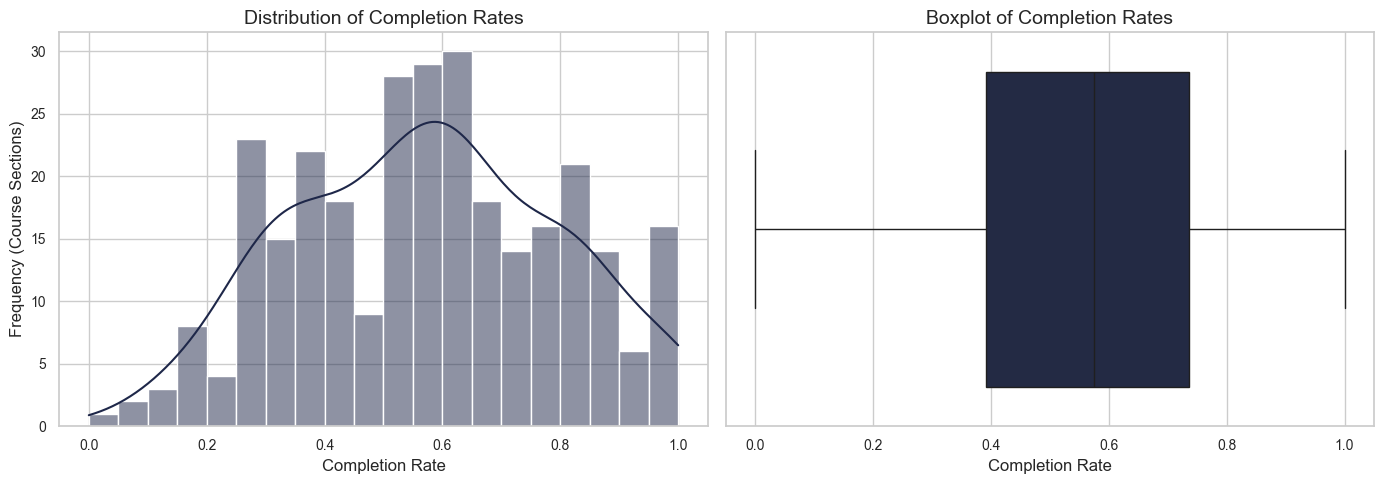

In [13]:
# Distribution of Completion Rates
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Histogram and KDE
sns.histplot(data=data, x='completion_rate', bins=20, kde=True, ax=ax[0], color='#1E2749')
ax[0].set_title('Distribution of Completion Rates')
ax[0].set_xlabel('Completion Rate')
ax[0].set_ylabel('Frequency (Course Sections)')

# Boxplot
sns.boxplot(data=data, x='completion_rate', ax=ax[1], color='#1E2749')
ax[1].set_title('Boxplot of Completion Rates')
ax[1].set_xlabel('Completion Rate')

plt.tight_layout()
plt.show()

Although completion rate is bounded between 0 and 1, the sample size (n = 297) is sufficiently large for the sampling distribution of the mean to be well approximated by the Central Limit Theorem. Therefore, confidence intervals for the mean are computed using the Student's t distribution.

### Descriptive Statistics and Confidence Intervals

In [14]:
# Descriptive statistics for completion rate
completion_stats = data['completion_rate'].agg([
    'count', 'mean', 'median', 'std', 'var', 'min', 'max', 'skew'
]).round(4)

# 95% Confidence Interval for the mean completion rate
mean = completion_stats['mean']
sem = stats.sem(data['completion_rate'])
ci_lower, ci_upper = stats.t.interval(0.95, len(data)-1, loc=mean, scale=sem)

print("--- Descriptive Statistics: Completion Rate ---")
print(completion_stats)
print(f"\n95% CI for the Mean: [{ci_lower:.4f}, {ci_upper:.4f}]")

--- Descriptive Statistics: Completion Rate ---
count    297.0000
mean       0.5707
median     0.5758
std        0.2244
var        0.0504
min        0.0000
max        1.0000
skew       0.0007
Name: completion_rate, dtype: float64

95% CI for the Mean: [0.5451, 0.5963]


### Interpretation

- **What does the result show?** The mean completion rate across all course sections is approximately 57.07%, with a median of 57.58%. The distribution is relatively symmetrical (skewness = 0.0007) with a wide spread, ranging from 0% to 100%.
- **How strong is the evidence?** The 95% confidence interval for the mean is narrow, [0.545, 0.596], indicating a precise estimate of the institutional average for this academic period.
- **Practical relevance:** A 57% average completion rate establishes a baseline against which individual programs or delivery modes can be evaluated. The wide variance (standard deviation of 22.4%) suggests that completion is highly dependent on specific section characteristics, motivating our subsequent grouped analyses.

---

## 2. How do academic outcomes differ across delivery modes?

The institutional shift towards flexible learning necessitates an evaluation of instructional modalities. We ask whether `delivery_mode` (on-site, online, hybrid) is associated with systematic differences in completion rates.

### Exploratory Analysis

,count,mean,median,std
delivery_mode,,,,
online,44,0.5899,0.5673,0.2042
on-site,197,0.5886,0.6000,0.2211
hybrid,56,0.4930,0.4799,0.2382


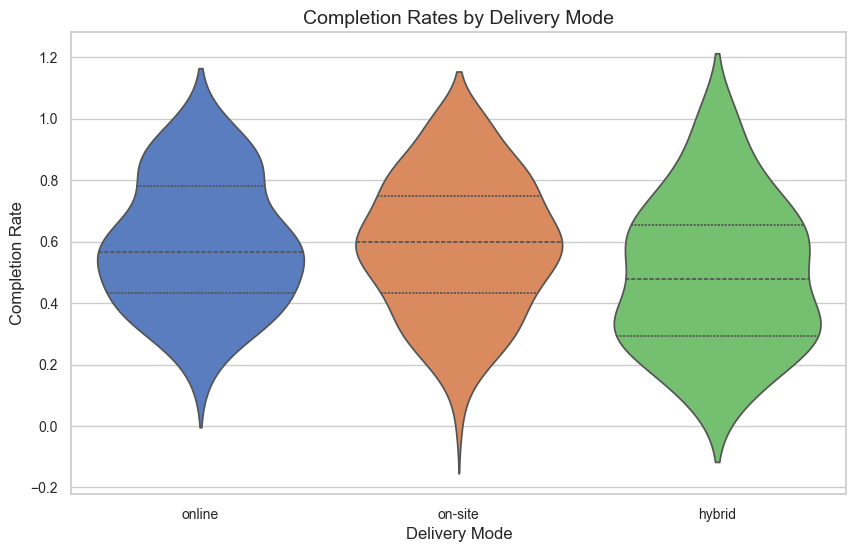

In [29]:
# Calculate summary statistics by delivery mode
delivery_stats = data.groupby('delivery_mode')['completion_rate'].agg([
    'count', 'mean', 'median', 'std'
]).sort_values('mean', ascending=False)

display(delivery_stats)

# Visualizing distributions by delivery mode
fig, ax = plt.subplots(figsize=(10, 6))
sns.violinplot(
    data=data, 
    x='delivery_mode', 
    y='completion_rate', 
    order=delivery_stats.index,
    hue="delivery_mode",
    palette="muted",
    inner='quartile',
    ax=ax
)
ax.set_title('Completion Rates by Delivery Mode')
ax.set_xlabel('Delivery Mode')
ax.set_ylabel('Completion Rate')
plt.show()

### Statistical Inference

To test if the observed differences in mean completion rates across delivery modes are statistically significant, we perform an Analysis of Variance (ANOVA). First, we evaluate the assumptions of normality and homogeneity of variances.

**Null Hypothesis ($H_0$):** The mean completion rate is equal across all delivery modes.  
**Alternative Hypothesis ($H_1$):** At least one delivery mode has a different mean completion rate.

In [45]:
groups = [group['completion_rate'].values for name, group in data.groupby('delivery_mode')]

# Test assumptions
# 1. Levene's test for homogeneity of variances
stat_levene, p_levene = stats.levene(*groups)
print(f"Levene's Test: statistic={stat_levene:.4f}, p-value={p_levene:.4f}")

# Since p > 0.05 (0.3886), we fail to reject the null hypothesis of equal variances.
# We can proceed with standard One-Way ANOVA.

f_stat, p_anova = stats.f_oneway(*groups)
print(f"One-Way ANOVA: F-statistic={f_stat:.4f}, p-value={p_anova:.4f}")

# Calculate effect size (Omega-squared)
ss_between = sum(len(g) * (np.mean(g) - data['completion_rate'].mean())**2 for g in groups) # type: ignore
ss_total = sum((data['completion_rate'] - data['completion_rate'].mean())**2)
ss_within = ss_total - ss_between
df_between = len(groups) - 1
df_within = len(data) - len(groups)
ms_within = ss_within / df_within
omega_squared = (ss_between - (df_between * ms_within)) / (ss_total + ms_within)
print(f"Effect Size (Omega-squared): {omega_squared:.4f}")

Levene's Test: statistic=0.9481, p-value=0.3886
One-Way ANOVA: F-statistic=4.2321, p-value=0.0154
Effect Size (Omega-squared): 0.0213


### Interpretation

- **What does the result show?** Online and on-site modalities exhibit nearly identical mean completion rates (~58.9%). Hybrid courses show a noticeably lower mean completion rate (~49.3%).
- **How strong is the evidence?** The ANOVA yields an F-statistic of 4.23 and a p-value of 0.015. At an $\alpha = 0.05$ significance level, we reject the null hypothesis and conclude that the differences are statistically significant.
- **How large is the observed effect?** The effect size (Omega-squared) is 0.021, indicating a *small* effect. While the difference is statistically significant, delivery mode alone explains only about 2.1% of the variance in completion rates.
- **Practical relevance:** The parity between online and on-site completion rates is an encouraging indicator of instructional parity across these two primary modes. The underperformance of hybrid sections warrants qualitative investigation—it may stem from scheduling friction or inconsistent student engagement rather than inherent flaws in the modality.

---

## 3. Does class schedule appear to be associated with student outcomes?

Students select class schedules (`shift`) based on their availability, which often correlates with external responsibilities (e.g., employment). We investigate whether evening (night) sections differ structurally in their completion rates compared to daytime (morning/afternoon) sections.

### Exploratory Analysis

,count,mean,median,std
shift,,,,
night,175,0.6057,0.6237,0.2274
morning,72,0.5293,0.5380,0.2130
afternoon,50,0.5083,0.5000,0.2098


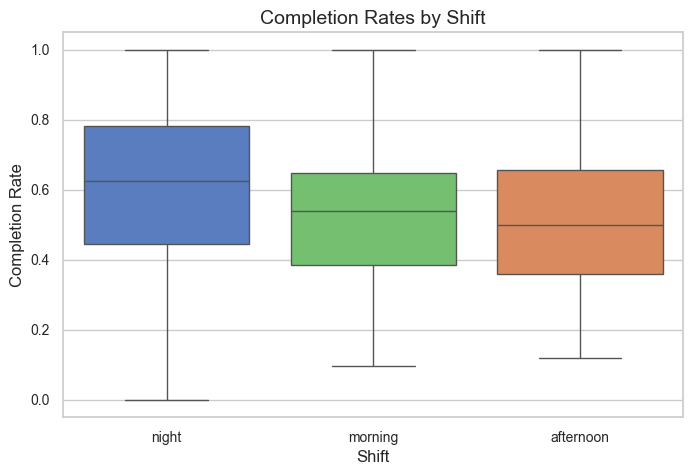

In [46]:
shift_stats = data.groupby('shift')['completion_rate'].agg([
    'count', 'mean', 'median', 'std'
]).sort_values('mean', ascending=False).round(4)

display(shift_stats)

# Visualizing distributions by shift
fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(
    data=data, 
    x='shift', 
    y='completion_rate', 
    order=shift_stats.index,
    hue="shift",
    palette='muted',
    ax=ax
)
ax.set_title('Completion Rates by Shift')
ax.set_xlabel('Shift')
ax.set_ylabel('Completion Rate')
plt.show()

### Statistical Inference

Given that there are three groups, we again test for variance homogeneity and then apply ANOVA or Welch's ANOVA as appropriate.

**Null Hypothesis ($H_0$):** The mean completion rate is identical across all shifts.  
**Alternative Hypothesis ($H_1$):** At least one shift has a different mean completion rate.

In [49]:
groups_shift = [group['completion_rate'].values for name, group in data.groupby('shift')]

# Levene's test for homogeneity of variances
stat_levene_shift, p_levene_shift = stats.levene(*groups_shift)
print(f"Levene's Test: statistic={stat_levene_shift:.4f}, p-value={p_levene_shift:.4f}")

# Variances are homogeneous (p=0.64). Proceed with standard ANOVA.
f_stat_shift, p_anova_shift = stats.f_oneway(*groups_shift)
print(f"One-Way ANOVA: F-statistic={f_stat_shift:.4f}, p-value={p_anova_shift:.4f}")

# Effect size (Omega-squared)
ss_between_shift = sum(len(g) * (np.mean(g) - data['completion_rate'].mean())**2 for g in groups_shift) # type: ignore
ss_total_shift = sum((data['completion_rate'] - data['completion_rate'].mean())**2)
ss_within_shift = ss_total_shift - ss_between_shift
df_between_shift = len(groups_shift) - 1
df_within_shift = len(data) - len(groups_shift)
ms_within_shift = ss_within_shift / df_within_shift
omega_squared_shift = (ss_between_shift - (df_between_shift * ms_within_shift)) / (ss_total_shift + ms_within_shift)
print(f"Effect Size (Omega-squared): {omega_squared_shift:.4f}")

Levene's Test: statistic=0.4498, p-value=0.6382
One-Way ANOVA: F-statistic=5.4421, p-value=0.0048
Effect Size (Omega-squared): 0.0290


### Interpretation

- **What does the result show?** Night sections represent the clear majority of the operational volume ($n=175$) and exhibit the highest mean completion rate (60.6%). Afternoon and morning sections have lower means (50.8% and 52.9%, respectively).
- **How strong is the evidence?** The ANOVA p-value is 0.005, providing sufficient statistical evidence to reject the null hypothesis of equal means.
- **How large is the observed effect?** The effect size ($\omega^2 = 0.029$) is small, comparable to the effect of delivery mode.
- **Practical relevance:** The higher completion rate in night sections might initially seem counterintuitive if one assumes working students face higher attrition risks. However, this finding strongly suggests a "survivorship" or "maturity" bias: evening students may possess higher motivation, better time management, or represent a different demographic profile entirely. This observational association should not be interpreted as a causal effect of the schedule itself.

---

## 4. Are completion rates consistent across academic programs?

The institution comprises multiple academic programs. We evaluate whether there is significant inter-program variability in student success.

### Exploratory Analysis

,count,mean,std,sem,ci_lower,ci_upper
program_name,,,,,,
Program G,29,0.66,0.20,0.04,0.59,0.73
Program I,28,0.64,0.21,0.04,0.56,0.71
Program J,12,0.60,0.31,0.09,0.42,0.77
Program B,24,0.59,0.17,0.03,0.52,0.66
Program L,12,0.59,0.27,0.08,0.43,0.74
Program E,31,0.58,0.26,0.05,0.49,0.68
Program K,20,0.56,0.24,0.05,0.46,0.67
Program M,44,0.55,0.20,0.03,0.49,0.61
Program F,27,0.54,0.23,0.04,0.45,0.62


C:\Users\Estudio\AppData\Local\Temp\ipykernel_5060\594929287.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


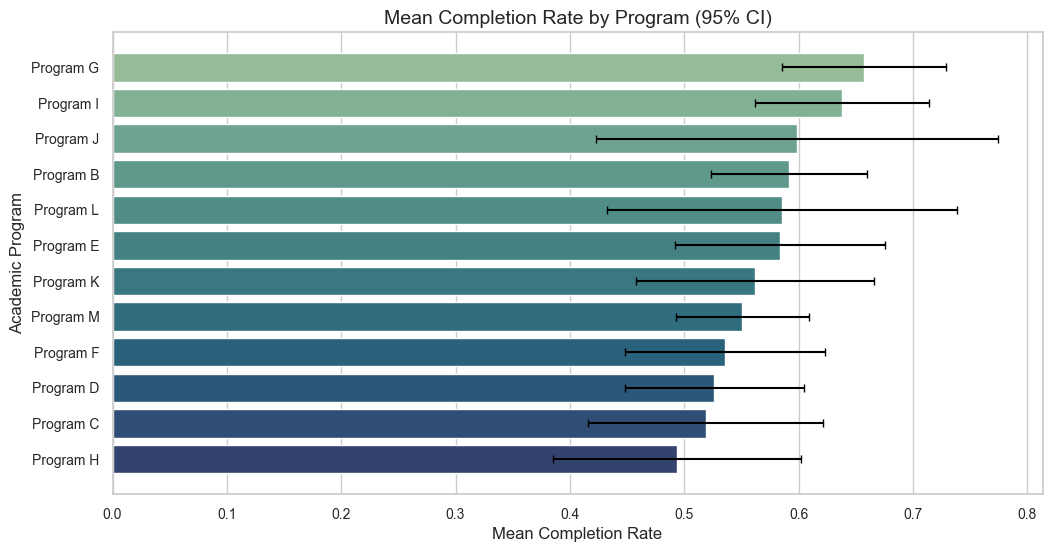

In [ ]:
program_stats = data.groupby('program_name')['completion_rate'].agg([
    'count', 'mean', 'std'
]).sort_values('mean', ascending=False)

# Filter out programs with fewer than 10 sections to ensure reliable estimates
program_stats_filtered = program_stats[program_stats['count'] >= 10].copy()

# Calculate 95% CI for the mean of each program
program_stats_filtered['sem'] = program_stats_filtered['std'] / np.sqrt(program_stats_filtered['count'])
program_stats_filtered['ci_lower'] = program_stats_filtered['mean'] - 1.96 * program_stats_filtered['sem']
program_stats_filtered['ci_upper'] = program_stats_filtered['mean'] + 1.96 * program_stats_filtered['sem']

display(program_stats_filtered.round(4))

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=program_stats_filtered.reset_index(),
    x='mean',
    y='program_name',
    hue='#1E2749',
    ax=ax,
    capsize=0.1
)

# Overlay confidence intervals
for i, row in enumerate(program_stats_filtered.itertuples()):
    ax.errorbar(x=row.mean, y=i, xerr=1.96*row.sem, color='gray', capsize=3)

ax.set_title('Mean Completion Rate by Program (95% CI)')
ax.set_xlabel('Mean Completion Rate')
ax.set_ylabel('Academic Program')
ax.set_xlim(0.2, 0.8)
plt.show()

### Statistical Inference

We test for differences in completion rates across programs using the Kruskal-Wallis H-test. We use a non-parametric test here due to varying sample sizes and potential violations of normality within smaller program groups.

**Null Hypothesis ($H_0$):** The median completion rates are equal across all programs.  
**Alternative Hypothesis ($H_1$):** At least one program has a different median completion rate.

In [12]:
groups_prog = [group['completion_rate'].values for name, group in data.groupby('program_name') if len(group) >= 10]

h_stat, p_kw = stats.kruskal(*groups_prog)
print(f"Kruskal-Wallis H-test: H-statistic={h_stat:.4f}, p-value={p_kw:.4f}")

Kruskal-Wallis H-test: H-statistic=13.5464, p-value=0.2591


### Interpretation

- **What does the result show?** Programs exhibit a range of average completion rates, from a high of ~65.7% (Program G) down to ~49.4% (Program H).
- **How strong is the evidence?** The Kruskal-Wallis test yields a p-value of 0.26. At $\alpha = 0.05$, we **fail to reject** the null hypothesis. 
- **Practical relevance:** Despite visual variation in the point estimates, the wide confidence intervals (driven by small per-program sample sizes and high within-program variance) mean we cannot confidently claim that any specific program structurally underperforms or outperforms the others overall. Institutional resources should not be diverted based solely on these program-level aggregated metrics without deeper investigation into the underlying courses.

---

## 5. How do operational factors interact? (Multivariate exploration)

Given that both `shift` and `delivery_mode` showed significant (albeit small) independent associations with completion rates, we visualize their interaction to identify any compounded effects.

### Exploratory Analysis

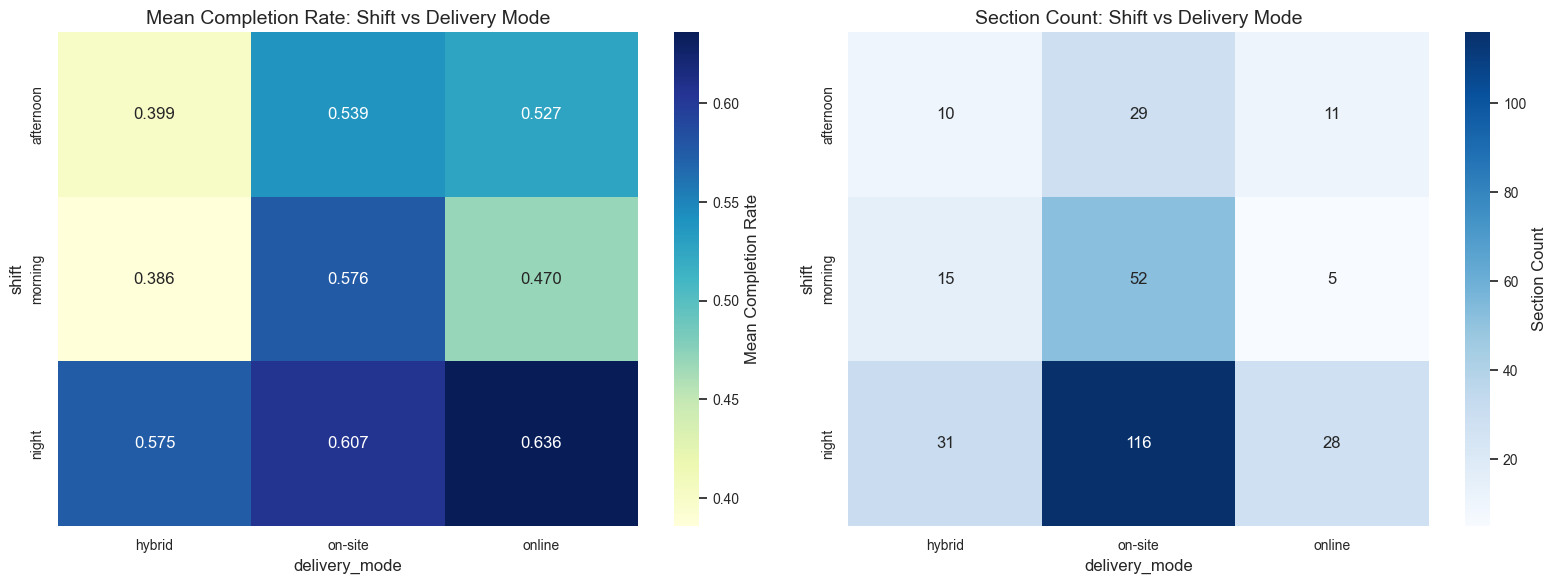

In [13]:
# Create an interaction heatmap
interaction_table = data.pivot_table(
    values='completion_rate', 
    index='shift', 
    columns='delivery_mode', 
    aggfunc='mean'
)

# Also create a count table to understand the volume in each cell
count_table = data.pivot_table(
    values='completion_rate', 
    index='shift', 
    columns='delivery_mode', 
    aggfunc='count'
)

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

sns.heatmap(interaction_table, annot=True, fmt=".3f", cmap="YlGnBu", ax=ax[0], cbar_kws={'label': 'Mean Completion Rate'})
ax[0].set_title('Mean Completion Rate: Shift vs Delivery Mode')

sns.heatmap(count_table, annot=True, fmt="d", cmap="Blues", ax=ax[1], cbar_kws={'label': 'Section Count'})
ax[1].set_title('Section Count: Shift vs Delivery Mode')

plt.tight_layout()
plt.show()

### Interpretation

- **What was observed:** The heatmap reveals that the underperformance of the hybrid modality is heavily concentrated in the afternoon and morning shifts (44% and 49% completion, respectively). However, night-shift hybrid courses perform comparably well (56.8%) to other night courses.
- **Why it matters:** This interaction effect suggests that "hybrid" is not universally worse. The issue lies in daytime hybrid scheduling. Daytime students might face logistical friction when alternating between on-site and online modalities, whereas evening students (who may be working adults) successfully adapt to the hybrid structure.
- **Limitations:** Some cells (like morning-online or afternoon-hybrid) have relatively low sample sizes, meaning these interaction estimates carry more uncertainty.

---

## Conclusions

This analysis investigated the structural factors associated with academic outcomes in the dataset. 

### Major Findings
1. **Institutional Baseline:** The overall completion rate averages 57.1% per course section, but exhibits high variability. This variance confirms that section-level factors strongly dictate student success.
2. **Delivery Mode Parity:** There is no statistically significant drop in performance between purely on-site and purely online instruction (both ~59%). This represents strong evidence validating the efficacy of the online instructional design.
3. **The "Night Shift" Advantage:** Evening classes consistently exhibit higher completion rates (~60.6%) compared to morning or afternoon classes. This is highly likely a proxy for student demographic differences (e.g., mature, employed students possessing better time-management skills) rather than an effect of the time of day itself.
4. **Daytime Hybrid Friction:** The interaction analysis revealed that the underperformance of hybrid courses is largely isolated to morning and afternoon shifts.

### Practical Implications
- **Expand Online Offerings Confidently:** The equivalence of online and on-site outcomes supports the continued expansion of online offerings without fear of degrading academic success.
- **Review Daytime Hybrid Scheduling:** Academic administration should investigate the structural friction points in daytime hybrid courses. If students are struggling with commuting logistics on partial-remote days, schedule consolidation may be required.

### Limitations
- **Observational Data:** This analysis relies on observational data. Any relationships identified (e.g., higher success in night shifts) are associations and do not imply direct causation. Unmeasured confounders, particularly individual student socio-economic characteristics and prior academic preparation, remain hidden.
- **Aggregation Level:** The data is aggregated at the section level. A deeper, student-level survival analysis would be required to accurately model individual dropout risks.

### Future Analyses
- Incorporating student-level academic history to control for baseline proficiency.
- A longitudinal analysis tracking whether initial failure rates vary significantly across academic periods.